# Part 7: Mini-Project

## Overview
This notebook contains our intermediate mini-project submission. It serves as an exploratory phase where we initially analyzed the dataset, tested preliminary hypotheses, and experimented with dimensionality reduction and visualization techniques (such as t-SNE). 

## Objectives
* Document the initial exploratory data analysis (EDA) and preliminary findings.
* Showcase early experiments with data visualization and dimensionality reduction.
* Highlight the foundational insights and conclusions that ultimately guided the development of our final clustering models.

# Miniproject

Goal: Indentifying different driving styles from official F1 data.

The dataset file: Qualifying_scaled_for_clustering.csv

### Imports:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## Part A: PCA

Selected k (>= 90% variance): 8


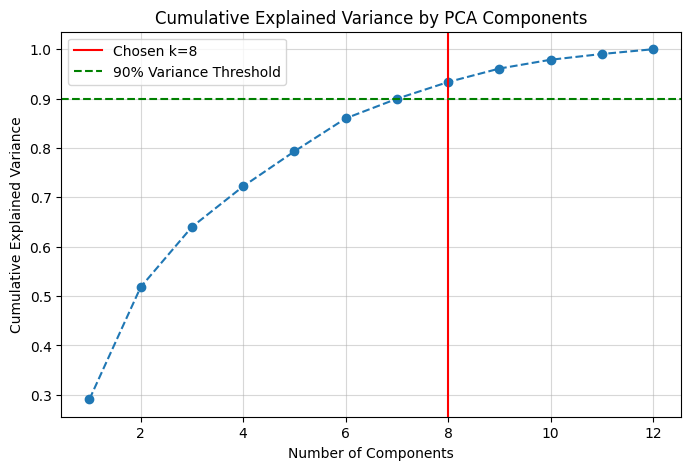

In [ ]:
# Load the dataset
df = pd.read_csv('../data/Qualifying_scaled_for_clustering.csv')

# Drop non-numeric columns before applying PCA
identifiers = ['track', 'global_corner_id', 'driver_number']
df_features = df.drop(columns=identifiers)

# 12.1: Apply PCA to the numeric dataset
pca = PCA()
pca.fit(df_features)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 12.3: Select a reasonable number of components (k) explaining at least 90% variance
k = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Selected k (>= 90% variance): {k}")

# 12.2: Plot the cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axvline(x=k, color='r', linestyle='-', label=f'Chosen k={k}')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% Variance Threshold')

plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

# Apply final PCA with the selected k
pca_final = PCA(n_components=k)
df_pca = pca_final.fit_transform(df_features)

* **How quickly does the explained variance grow?**
The explained variance grows gradually and steadily. There is no sharp "elbow" in the early components, indicating that the information in the F1 telemetry dataset is distributed across several variables rather than being concentrated in just one or two.
* **What value of (k) seems reasonable?**
A value of $k=8$ is reasonable. At this point, the cumulative explained variance crosses the 90% threshold, providing a good balance between reducing dimensionality and retaining critical information.
* **Does PCA appear useful for visualization, clustering, or data compression?**
* **Visualization:** Not very useful. The first 2-3 components explain less than 65% of the variance, meaning a standard 2D or 3D scatter plot would fail to represent a significant portion of the data structure.
* **Clustering & Data Compression:** Moderately useful. It reduces the feature space to 8 dimensions while keeping 90% of the variance, which compresses the data and can help remove noise before applying clustering algorithms.

## Part B: t-SNE:

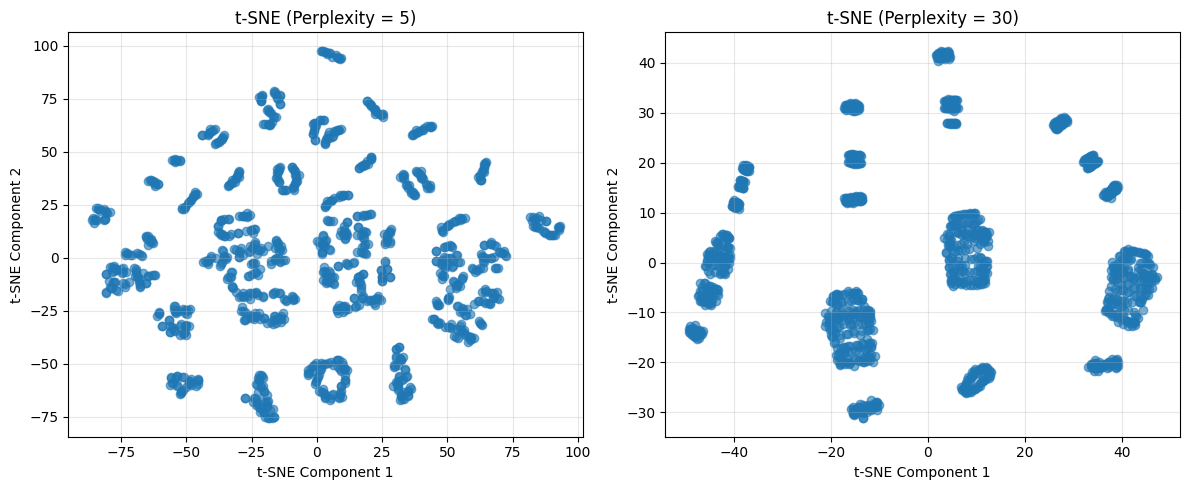

In [ ]:
# Define the perplexity values to test
perplexities = [5, 30]

plt.figure(figsize=(12, 5))

for i, p in enumerate(perplexities, 1):
    # Initialize and fit t-SNE
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    
    # We use df_numeric from the previous step
    tsne_results = tsne.fit_transform(df_features)

    # Plot the results
    plt.subplot(1, len(perplexities), i)
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.6)
    plt.title(f't-SNE (Perplexity = {p})')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* **Which apparent groups or patterns remain visible across different perplexity values?**
Both plots clearly demonstrate that the data is not uniformly distributed. Regardless of the perplexity setting, the data points naturally aggregate into distinct, dense pockets rather than forming a single continuous mass.
* **Which aspects of the visualization change noticeably when the perplexity changes?**
Cluster fragmentation and overall size. At perplexity 5, the data splinters into dozens of tiny, isolated "micro-clusters" because the algorithm only looks at immediate neighbors. At perplexity 30, it considers a wider neighborhood, effectively merging these scattered fragments into fewer, larger, and much more cohesive macro-clusters.
* **Does t-SNE reveal structure that was not obvious in the original feature space?**
Yes. The original feature space is high-dimensional (as demonstrated by the earlier PCA step), making visual structure impossible to detect. t-SNE successfully maps these complex relationships into 2D, clearly exposing separated groupings. In the context of telemetry, these distinct clusters likely represent specific, repeating track segments like corners and straights, or distinct driving profiles.

# Part D: Discussion

* **Usefulness of PCA/NMF:** PCA proved highly useful for this dataset. It successfully reduced the high-dimensional telemetry data to 8 principal components while retaining over 90% of the variance. This provides a compressed, noise-reduced representation that is ideal as an input for clustering algorithms.
* **Visual Insight from t-SNE:** t-SNE provided excellent visual insight. While the data's underlying structure was completely hidden in the original high-dimensional space, t-SNE (specifically at a higher perplexity of 30) revealed distinct, dense macro-clusters. This confirms that the data contains natural, separable groupings.
* **Implementation in the Final Project:** We plan to utilize both methods in the final project pipeline. PCA will serve as a mandatory preprocessing step for dimensionality reduction to improve the efficiency and accuracy of the clustering algorithm. t-SNE will be used exclusively as a post-clustering evaluation tool to visualize the final clusters in 2D and assess their quality.
* **Representation vs. Visualization:** This process highlighted a key difference: Representation (PCA) transforms the data to preserve mathematical structure and global variance, creating a reliable, compressed state for algorithms to process. Visualization (t-SNE) projects data into 2D/3D purely for human interpretation, intentionally distorting actual distances to emphasize local neighborhoods. Therefore, representation is for machines, and visualization is for human eyes.